# Faster R-CNN Insect Detector — Evaluation Notebook (Single Class)

This notebook is a **ready-to-run evaluation workflow** for a Faster R-CNN model trained on a **single object class** (e.g., `insect`) in **COCO format**.

It covers:

- Loading a trained checkpoint (e.g., `best_model.pt`)
- Building the *exact* Faster R-CNN model architecture used in training
- Preparing a COCO-format test set
- Computing **mAP** metrics with `torchmetrics`
- Visualizing predictions vs. ground-truth bounding boxes

> **Tip:** Run cells top-to-bottom. You only need to edit the paths in the **Configuration** section.


## 1) Install / Requirements

You need these packages:

- `torch`, `torchvision`
- `torchmetrics`
- `matplotlib`
- `tqdm`

If you're running in a fresh environment (e.g., Colab), you can install missing packages like this:


In [1]:
# If needed, uncomment and run:
# !pip install -U torch torchvision torchmetrics matplotlib tqdm

## 2) Configuration (edit these paths)

Set:

- `COCO_ROOT`: dataset root that contains `test/images/` and `test/annotations.json`
- `CHECKPOINT_PATH`: path to your trained checkpoint (default: `best_model.pt`)

Expected dataset layout:

```
COCO_ROOT/
  test/
    images/
      0001.jpg
      ...
    annotations.json
```

Where `annotations.json` follows the COCO schema with keys `images` and `annotations`.


In [2]:
from pathlib import Path

# --- Dataset root (COCO-format) ---
COCO_ROOT = Path("../dataset/splitted_coco_dataset_single_class")  # <-- EDIT if needed

TEST_IMG_DIR = COCO_ROOT / "test" / "images"
TEST_JSON    = COCO_ROOT / "test" / "annotations.json"

# --- Model checkpoint ---
CHECKPOINT_PATH = Path("best_model.pt")  # <-- EDIT if your file has a different name/path

print("CWD:", Path.cwd())
print("TEST images dir:", TEST_IMG_DIR)
print("TEST annotations:", TEST_JSON)
print("Checkpoint:", CHECKPOINT_PATH)

assert TEST_IMG_DIR.exists(), f"Missing: {TEST_IMG_DIR}"
assert TEST_JSON.exists(), f"Missing: {TEST_JSON}"
assert CHECKPOINT_PATH.exists(), f"Missing: {CHECKPOINT_PATH}"

CWD: c:\Users\ofaru\Desktop\AI for Society\Group Project\Project Itself\Final version\model inference
TEST images dir: ..\dataset\splitted_coco_dataset_single_class\test\images
TEST annotations: ..\dataset\splitted_coco_dataset_single_class\test\annotations.json
Checkpoint: best_model.pt


## 3) Imports + device

We select GPU if available. The same notebook works on CPU (just slower).


In [3]:
import json
from typing import Dict, List
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


## 4) Dataset: COCO (single class)

This dataset assumes **one foreground class**.  
All ground-truth boxes get label `1` (label `0` is reserved for background internally).

COCO bounding boxes are stored as `[x, y, width, height]` and are converted to `[x1, y1, x2, y2]`.


In [4]:
from PIL import Image

class CocoSingleClassDataset(Dataset):
    """COCO-format dataset for a single foreground class.

    - Expects COCO JSON with `images` and `annotations`
    - Converts COCO bbox XYWH -> XYXY
    - Assigns label=1 for every annotation (single class)
    """
    def __init__(self, img_dir: Path, ann_path: Path, transforms=None):
        self.img_dir = Path(img_dir)
        self.ann_path = Path(ann_path)
        self.transforms = transforms

        with open(self.ann_path, "r", encoding="utf-8") as f:
            coco = json.load(f)

        self.images = coco.get("images", [])
        anns = coco.get("annotations", [])

        # image_id -> image info
        self.id_to_img = {img["id"]: img for img in self.images}

        # group annotations by image_id
        self.ann_by_img: Dict[int, List[dict]] = {img["id"]: [] for img in self.images}
        for ann in anns:
            img_id = ann.get("image_id")
            if img_id in self.ann_by_img:
                self.ann_by_img[img_id].append(ann)

        self.image_ids = [img["id"] for img in self.images]

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx: int):
        image_id = self.image_ids[idx]
        img_info = self.id_to_img[image_id]
        img_path = self.img_dir / img_info["file_name"]

        # Load image (RGB)
        image = Image.open(img_path).convert("RGB")

        anns = self.ann_by_img.get(image_id, [])

        boxes = []
        areas = []
        iscrowd = []

        for ann in anns:
            # COCO bbox: [x, y, w, h]
            x, y, w, h = ann["bbox"]
            x1, y1 = float(x), float(y)
            x2, y2 = float(x + w), float(y + h)
            boxes.append([x1, y1, x2, y2])
            areas.append(float(w * h))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            areas_t = torch.zeros((0,), dtype=torch.float32)
            iscrowd_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.ones((len(boxes),), dtype=torch.int64)  # single class -> label 1
            areas_t = torch.tensor(areas, dtype=torch.float32)
            iscrowd_t = torch.tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([image_id]),
            "area": areas_t,
            "iscrowd": iscrowd_t,
        }

        if self.transforms is not None:
            image = self.transforms(image)

        return image, target


def collate_fn(batch):
    # torchvision detection models expect: List[Tensor], List[Dict]
    return tuple(zip(*batch))

## 5) Transforms + DataLoader

These transforms match a common training setup: convert to tensor and scale to `[0, 1]` float32.


In [5]:
val_tfms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

test_ds = CocoSingleClassDataset(TEST_IMG_DIR, TEST_JSON, transforms=val_tfms)

test_loader = DataLoader(
    test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

print("Test images:", len(test_ds))

Test images: 1002


## 6) Build the model + load checkpoint

This recreates the exact architecture used in training:

- `fasterrcnn_resnet50_fpn(weights="DEFAULT")`
- Replace the predictor head for **2 classes**: background + insect.

Then we load the trained weights from `CHECKPOINT_PATH`.


In [6]:
# Build model (must match training)
num_classes = 2  # background + 1 class (insect)

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Load checkpoint
state = torch.load(CHECKPOINT_PATH, map_location=device)
# Some PyTorch versions store full dict; support both cases:
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

model.load_state_dict(state)
model.to(device)
model.eval()

print(f"Loaded checkpoint: {CHECKPOINT_PATH}")

C:\Users\ofaru\AppData\Local\Temp\ipykernel_47136\3724954334.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CHECKPOINT_PATH, map_location=device)


Loaded checkpoint: best_model.pt


## 7) Compute mAP (torchmetrics)

We compute:

- `mAP@[0.50:0.95]` (COCO-style)
- `mAP@0.50`
- `mAP@0.75`
- `mar@100`

`score_thr` controls which predictions are considered (filter low-confidence detections).


In [7]:
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def evaluate_map_torchmetrics(model, data_loader, device, score_thr: float = 0.05):
    metric = MeanAveragePrecision(iou_type="bbox")
    model.eval()

    for images, targets in tqdm(data_loader, desc="Evaluating mAP"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds, gts = [], []
        for out, tgt in zip(outputs, targets):
            boxes  = out["boxes"].detach().cpu()
            scores = out["scores"].detach().cpu()
            labels = out["labels"].detach().cpu()

            keep = scores >= score_thr
            preds.append({
                "boxes": boxes[keep],
                "scores": scores[keep],
                "labels": labels[keep],
            })

            gts.append({
                "boxes": tgt["boxes"].detach().cpu(),
                "labels": tgt["labels"].detach().cpu(),
            })

        metric.update(preds, gts)

    r = metric.compute()
    return {
        "mAP_50_95": float(r["map"]),
        "mAP_50": float(r["map_50"]),
        "mAP_75": float(r["map_75"]),
        "mar_100": float(r["mar_100"]),
    }

results_test = evaluate_map_torchmetrics(model, test_loader, device, score_thr=0.05)
results_test

Evaluating mAP: 100%|██████████| 501/501 [01:26<00:00,  5.80it/s]


{'mAP_50_95': 0.8166284561157227,
 'mAP_50': 0.8929338455200195,
 'mAP_75': 0.8829048275947571,
 'mar_100': 0.9367647171020508}

## 8) Visual inspection: predictions vs. ground truth

This section randomly samples images from the test set and draws:

- **Green** boxes: Ground truth (GT)
- **Red** boxes: Predictions (filtered by `score_thr`)

Visual checks are important because good metrics can still hide failure modes (e.g., missing small objects).


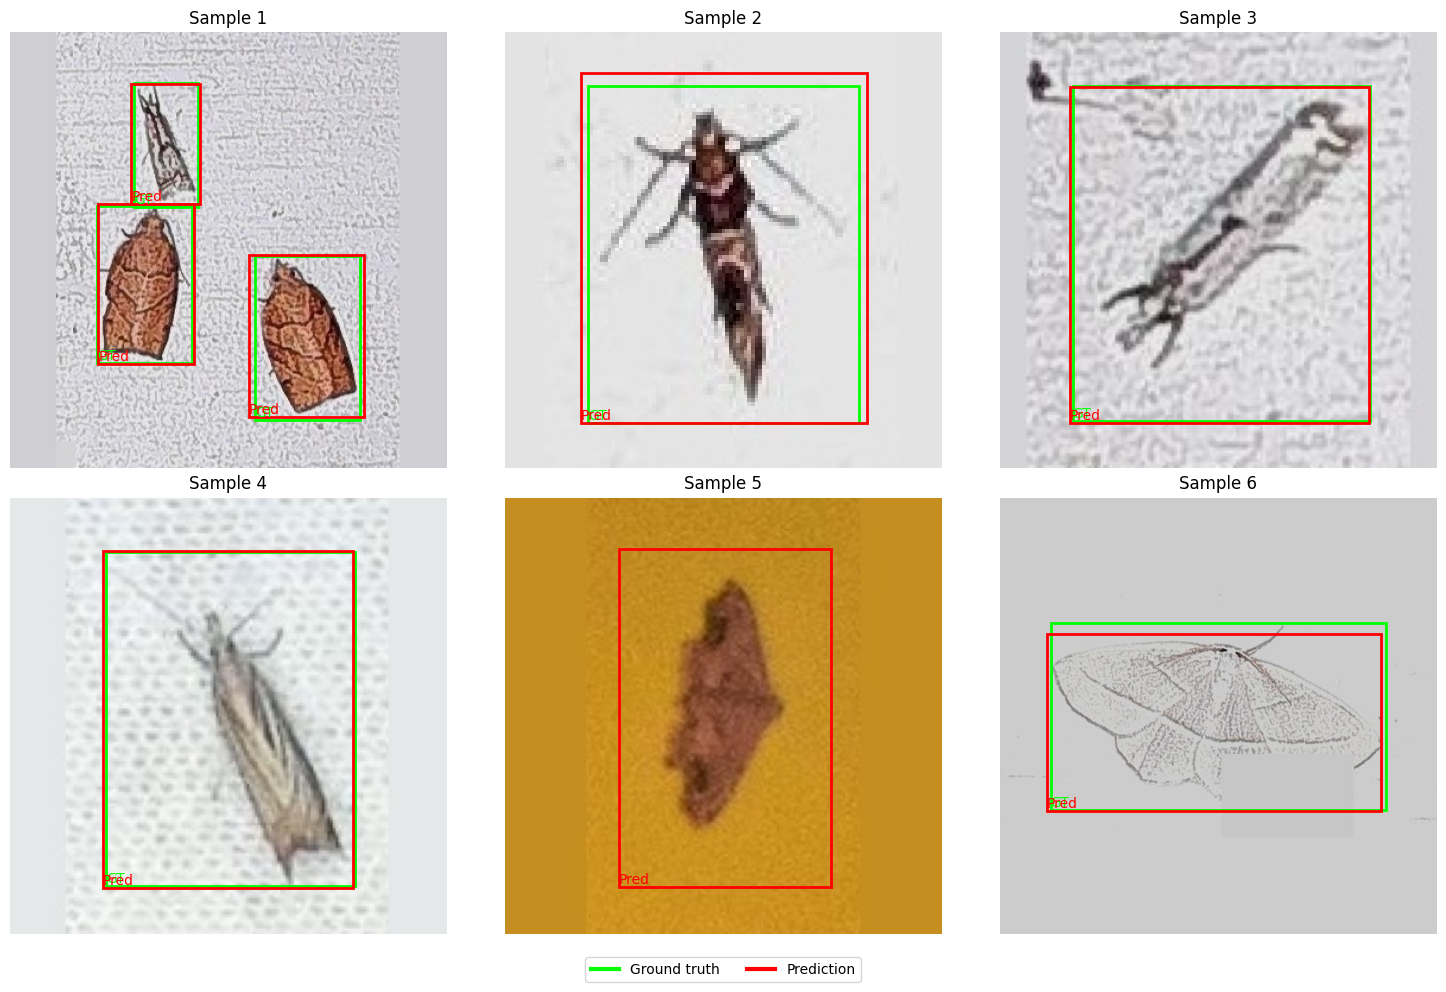

In [8]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def predict_one(image_tensor, model, device):
    model.eval()
    with torch.no_grad():
        out = model([image_tensor.to(device)])[0]
    return {k: v.detach().cpu() for k, v in out.items()}

def draw_boxes(ax, boxes, edgecolor, label_text=None, linewidth=2):
    for b in boxes:
        x1, y1, x2, y2 = [float(v) for v in b]
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=edgecolor, linewidth=linewidth))
        if label_text:
            ax.text(x1, y2, label_text, fontsize=10, color=edgecolor, verticalalignment="bottom")

# --- Sampling ---
random.seed(38)
n_samples = 6
idxs = random.sample(range(len(test_ds)), k=min(n_samples, len(test_ds)))
samples = [test_ds[i] for i in idxs]

score_thr = 0.5
plt.figure(figsize=(15, 10))

for i, (img, tgt) in enumerate(samples, 1):
    pred = predict_one(img, model, device)
    keep = pred["scores"] >= score_thr
    pred_boxes = pred["boxes"][keep]

    img_np = img.permute(1, 2, 0).numpy()
    ax = plt.subplot(2, 3, i)
    ax.imshow(img_np)
    ax.set_title(f"Sample {i}")
    ax.axis("off")

    draw_boxes(ax, tgt["boxes"], "lime", "GT", 2)
    draw_boxes(ax, pred_boxes, "red", "Pred", 2)

legend_elements = [
    Line2D([0], [0], color="lime", lw=3, label="Ground truth"),
    Line2D([0], [0], color="red", lw=3, label="Prediction"),
]

plt.figlegend(handles=legend_elements, loc="lower center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 9) (Optional) Save evaluation results

This writes your metrics to a JSON file next to the notebook.


In [9]:
import json
from datetime import datetime

out_metrics_path = Path(f"eval_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")
with open(out_metrics_path, "w", encoding="utf-8") as f:
    json.dump(results_test, f, indent=2)

print("Saved:", out_metrics_path.resolve())

Saved: C:\Users\ofaru\Desktop\AI for Society\Group Project\Project Itself\Final version\model inference\eval_metrics_20260126_163849.json
